In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Kütüphaneler başarıyla yüklendi.")

✅ Kütüphaneler başarıyla yüklendi.


In [16]:

url = "https://raw.githubusercontent.com/Efeyamann/LiverDiseaseAnalysis/main/indian_liver_patient.csv"
df = pd.read_csv(url)
print("✅ Veri GitHub üzerinden başarıyla çekildi.")

✅ Veri GitHub üzerinden başarıyla çekildi.


In [17]:
turkce_basliklar = {
    'Age': 'Yaş',
    'Gender': 'Cinsiyet',
    'Total_Bilirubin': 'Toplam Bilirubin',
    'Direct_Bilirubin': 'Doğrudan Bilirubin',
    'Alkaline_Phosphotase': 'Alkalen Fosfataz',
    'Alamine_Aminotransferase': 'Alanin Aminotransferaz',
    'Aspartate_Aminotransferase': 'Aspartat Aminotransferaz',
    'Total_Protiens': 'Toplam Proteinler',
    'Albumin': 'Albümin',
    'Albumin_and_Globulin_Ratio': 'Albümin/Globülin Oranı',
    'Dataset': 'Sonuç'
}

df.rename(columns=turkce_basliklar, inplace=True)

print("--- VERİ SETİNİN İLK 5 SATIRI (TÜRKÇE) ---")
display(df.head())

print("\n--- VERİ SETİ ÖZETİ ---")
df.info()

--- VERİ SETİNİN İLK 5 SATIRI (TÜRKÇE) ---


,Yaş,Cinsiyet,Toplam Bilirubin,Doğrudan Bilirubin,Alkalen Fosfataz,Alanin Aminotransferaz,Aspartat Aminotransferaz,Toplam Proteinler,Albümin,Albümin/Globülin Oranı,Sonuç
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1



--- VERİ SETİ ÖZETİ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Yaş                       583 non-null    int64  
 1   Cinsiyet                  583 non-null    object 
 2   Toplam Bilirubin          583 non-null    float64
 3   Doğrudan Bilirubin        583 non-null    float64
 4   Alkalen Fosfataz          583 non-null    int64  
 5   Alanin Aminotransferaz    583 non-null    int64  
 6   Aspartat Aminotransferaz  583 non-null    int64  
 7   Toplam Proteinler         583 non-null    float64
 8   Albümin                   583 non-null    float64
 9   Albümin/Globülin Oranı    579 non-null    float64
 10  Sonuç                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [18]:
df['Albümin/Globülin Oranı'] = df['Albümin/Globülin Oranı'].fillna(df['Albümin/Globülin Oranı'].median())
df['Cinsiyet'] = df['Cinsiyet'].map({'Male': 1, 'Female': 0})
df['Sonuç'] = df['Sonuç'].map({1: 1, 2: 0})

X = df.drop('Sonuç', axis=1)
y = df['Sonuç']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Veri temizlendi ve eğitime hazır hale getirildi.")

✅ Veri temizlendi ve eğitime hazır hale getirildi.


In [19]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("✅ İki model de başarıyla eğitildi.")

✅ İki model de başarıyla eğitildi.


Random Forest Başarısı: %70.94
XGBoost Başarısı:       %70.09


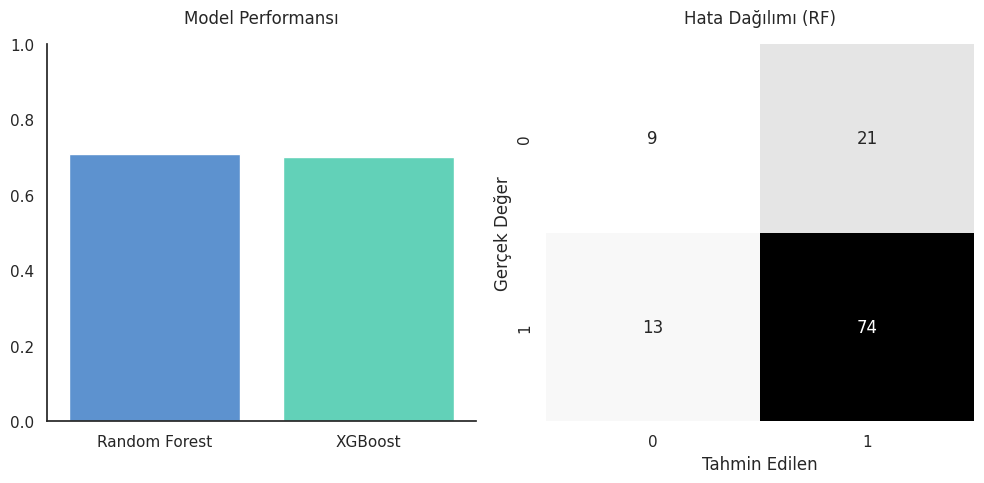

In [20]:
# Doğruluk
rf_acc = accuracy_score(y_test, rf_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"Random Forest Başarısı: %{rf_acc*100:.2f}")
print(f"XGBoost Başarısı:       %{xgb_acc*100:.2f}")

plt.figure(figsize=(10, 5))
sns.set_style("white")

plt.subplot(1, 2, 1)
colors = ["#4A90E2", "#50E3C2"]
ax = sns.barplot(x=['Random Forest', 'XGBoost'], y=[rf_acc, xgb_acc], palette=colors)
plt.title('Model Performansı', fontsize=12, pad=15)
plt.ylim(0, 1)
sns.despine()

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greys', cbar=False)
plt.title('Hata Dağılımı (RF)', fontsize=12, pad=15)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')

plt.tight_layout()
plt.show();

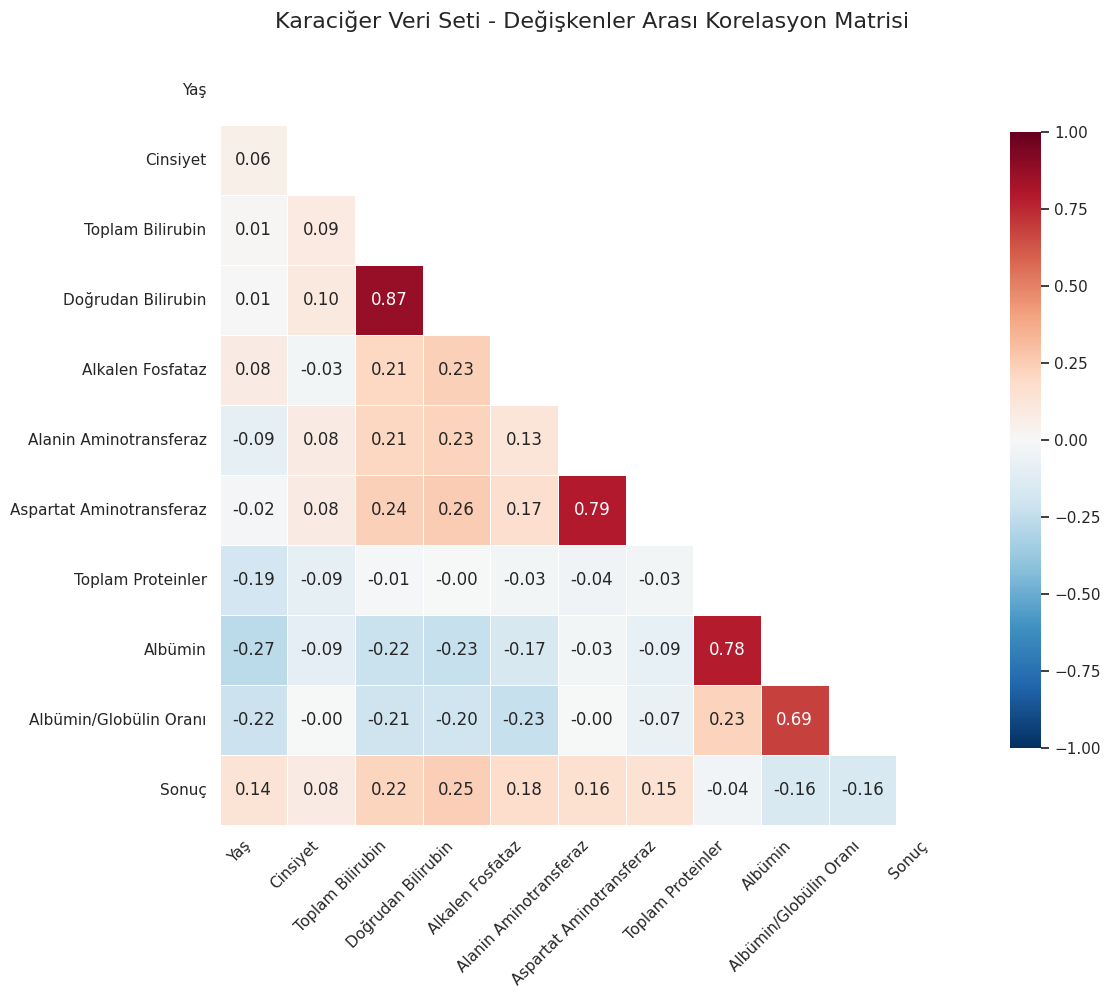

In [21]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

heatmap = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Karaciğer Veri Seti - Değişkenler Arası Korelasyon Matrisi', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()